In [3]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/parkinsons/analysis')


In [4]:
import os
from load_data.load_npz import load_spikedata
from analysis.position_sd import get_neuron_positions, compute_distance_matrix
from analysis.firing_sd import isi, cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
sd24578_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24578_D49-6.zip')
sd24578_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24578_D60+6.zip')
sd24481_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24481_D49-6.zip')
sd24481_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24481_D60+6.zip')

In [ ]:
acg24481_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/default/d49/24481_SmitsMO_D49_sect300_20241031_params_default_conn/acg.npz'
fc24481_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/default/d49/24481_SmitsMO_D49_sect300_20241031_params_default_conn/func_pairs.npz'
acg24578_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/default/d49/24578_SmitsMO_D49_sect300_20241031_params_default_conn/acg.npz'
fc24578_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/default/d49/24578_SmitsMO_D49_sect300_20241031_params_default_conn/func_pairs.npz'
acg24481_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/default/60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_default_conn/acg.npz'
fc24481_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/default/d60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_default_conn/func_pairs.npz'
acg24578_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/default/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_default_conn/acg.npz' 
fc24578_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/default/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_default_conn/func_pairs.npz'

In [7]:
acg24481_49 = np.load(acg24481_49_path, allow_pickle=True)
fc24481_49 = np.load(fc24481_49_path, allow_pickle=True)
acg24578_49 = np.load(acg24578_49_path, allow_pickle=True)
fc24578_49 = np.load(fc24578_49_path, allow_pickle=True)
acg24481_60 = np.load(acg24481_60_path, allow_pickle=True)
fc24481_60 = np.load(fc24481_60_path, allow_pickle=True)
acg24578_60 = np.load(acg24578_60_path, allow_pickle=True)
fc24578_60 = np.load(fc24578_60_path, allow_pickle=True)


In [8]:
ac24481_49 = acg24481_49['acg_dict'].item()
print(len(ac24481_49))
ac24481_60 = acg24481_60['acg_dict'].item()
print(len(ac24481_60))
ac24578_49 = acg24578_49['acg_dict'].item()
print(len(ac24578_49))
ac24578_60 = acg24578_60['acg_dict'].item()
print(len(ac24578_60))

403
207
378
255


In [9]:
fp24481_49 = fc24481_49['func_pairs'].item()
print(len(fp24481_49))
fp24481_60 = fc24481_60['func_pairs'].item()
print(len(fp24481_60))
fp24578_49 = fc24578_49['func_pairs'].item()
print(len(fp24578_49))
fp24578_60 = fc24578_60['func_pairs'].item()
print(len(fp24578_60))


55
22
125
109


In [10]:
fplist_24481 = [fp24481_49, fp24481_60]
fplist_24578 = [fp24578_49, fp24578_60]
labels_24481 = ['D49', 'D60']
labels_24578 = ['D49', 'D60']

In [11]:
sdlist_24481 = [sd24481_49, sd24481_60]
sdlist_24578 = [sd24578_49, sd24578_60]

In [8]:
print(ac24481_49.keys())
print(ac24481_60.keys())
print(ac24578_49.keys())
print(ac24578_60.keys())

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

In [ ]:
def extract_func_pair_metrics(func_pairs):
    """
    Extract latency, p_fast, and max CCG peak from each functional pair.
    
    Parameters:
        func_pairs (dict): Dictionary where each key is a tuple (sender, receiver)
                           and each value is a dictionary containing at least:
                             - 'latency': peak latency (ms)
                             - 'p_fast': the p-value for fast transmission
                             - 'ccg': an array of CCG counts
                             
    Returns:
        tuple: Three numpy arrays for latencies, p_fast values, and max CCG peaks.
    """
    latencies = []
    p_fast_values = []
    max_peaks = []
    for key, info in func_pairs.items():
        latencies.append(info['latency'])
        p_fast_values.append(info['p_fast'])
        max_peaks.append(np.max(info['ccg']))
    return np.array(latencies), np.array(p_fast_values), np.array(max_peaks)

def plot_func_pair_metrics(func_pairs, title="Chip ID: Day"):
    """
    Extract and plot distributions of functional pair metrics.
    
    This function:
      - Extracts latency, p_fast, and maximum CCG peak counts from the functional pairs.
      - Plots histograms for each metric.
      - Creates a 2D heatmap of latency versus max CCG count.
      
    Parameters:
        func_pairs (dict): Dictionary of functional pairs.
        title (str): Title string to append to each plot title (default "Chip ID: Day").
    """
    # Extract metrics
    latencies, p_fast_values, max_peaks = extract_func_pair_metrics(func_pairs)
    
    # Plot histograms for each metric
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    
    axs[0].hist(latencies, bins=20, color='skyblue')
    axs[0].set_title(f"Latency Distribution (ms): {title}")
    axs[0].set_xlabel("Latency (ms)")
    axs[0].set_ylabel("Count")
    
    axs[1].hist(p_fast_values, bins=20, color='salmon')
    axs[1].set_title(f"p_fast Distribution: {title}")
    axs[1].set_xlabel("p_fast")
    axs[1].set_ylabel("Count")
    
    axs[2].hist(max_peaks, bins=20, color='lightgreen')
    axs[2].set_title(f"CCG Peak Count Distribution: {title}")
    axs[2].set_xlabel("Max CCG Count")
    axs[2].set_ylabel("Count")
    
    plt.tight_layout()
    plt.show()
    
    # Plot a 2D heatmap of latency vs. max CCG peak
    heatmap, xedges, yedges = np.histogram2d(latencies, max_peaks, bins=20)
    plt.figure(figsize=(6,5))
    plt.imshow(heatmap.T, origin='lower', aspect='auto',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               cmap='viridis')
    plt.colorbar(label='Count')
    plt.xlabel("Latency (ms)")
    plt.ylabel("Max CCG Count")
    plt.title(f"Heatmap: Latency vs. Max CCG Count: {title}")
    plt.show()


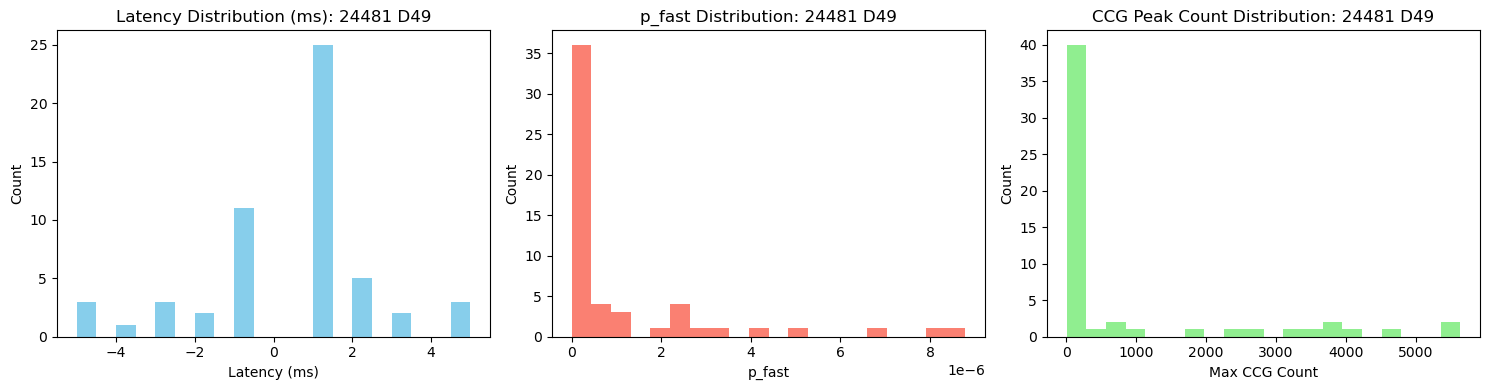

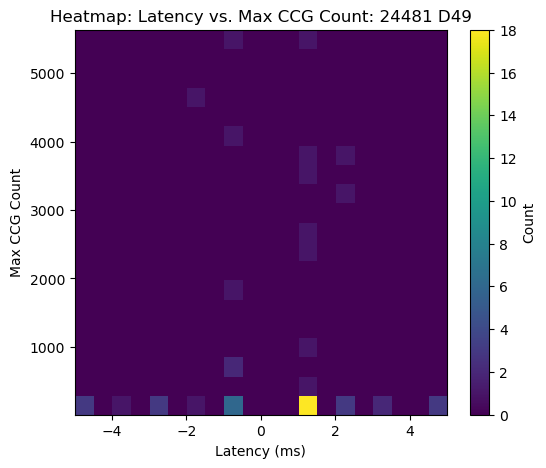

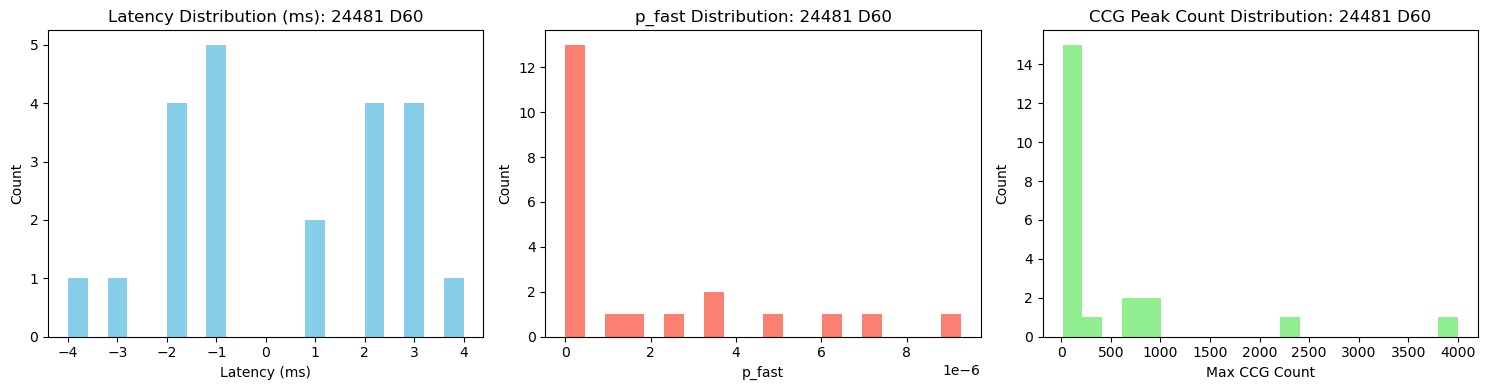

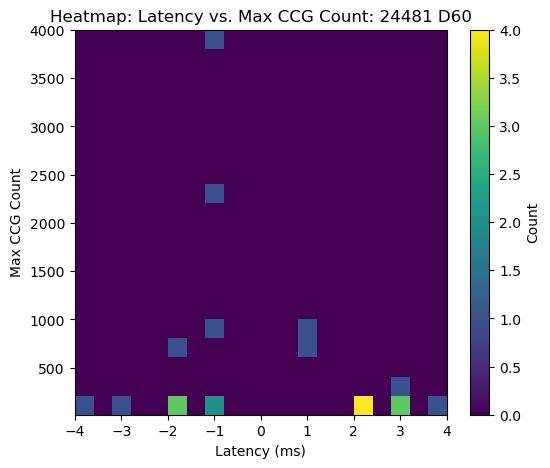

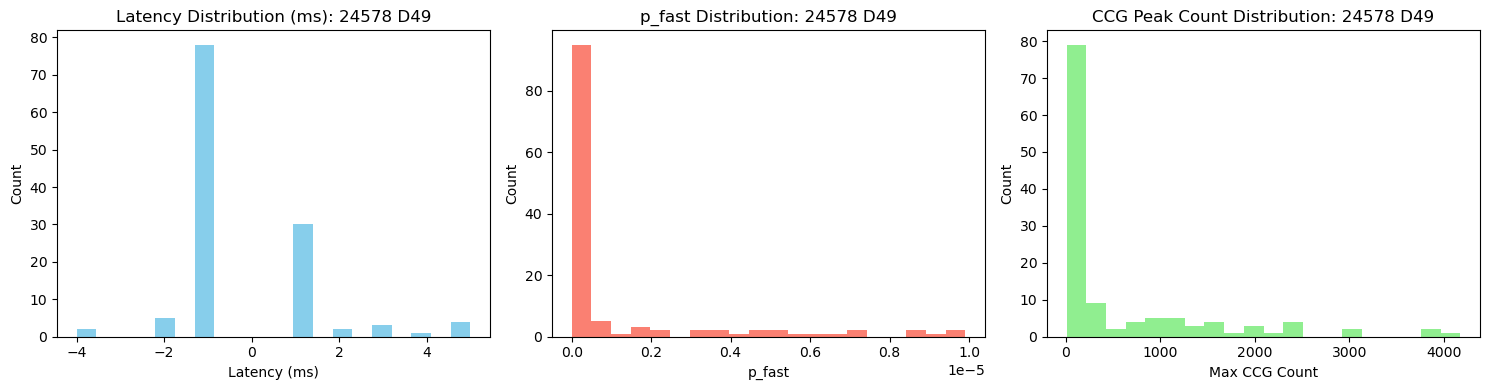

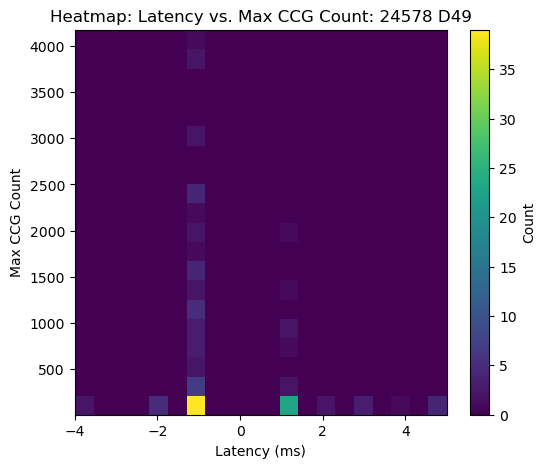

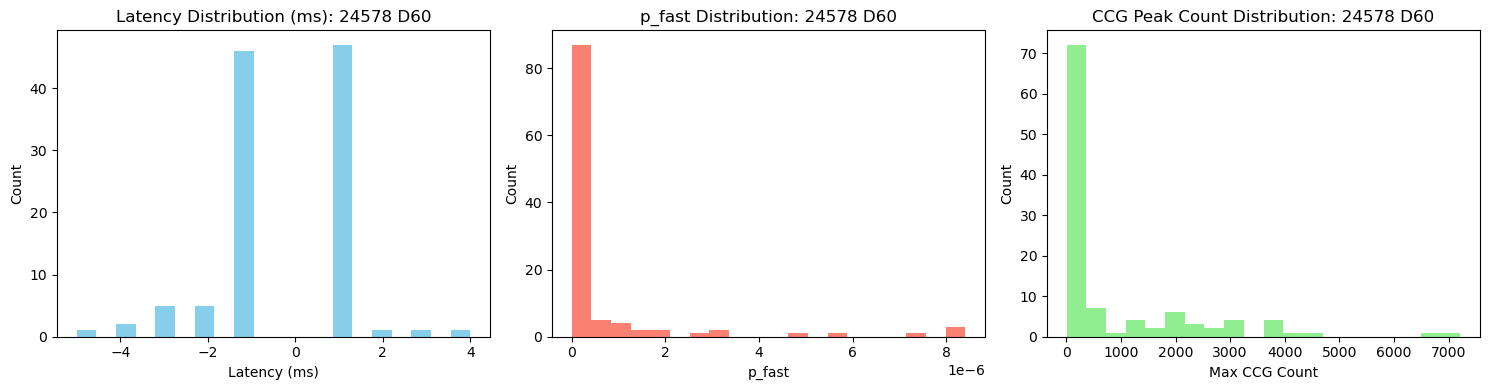

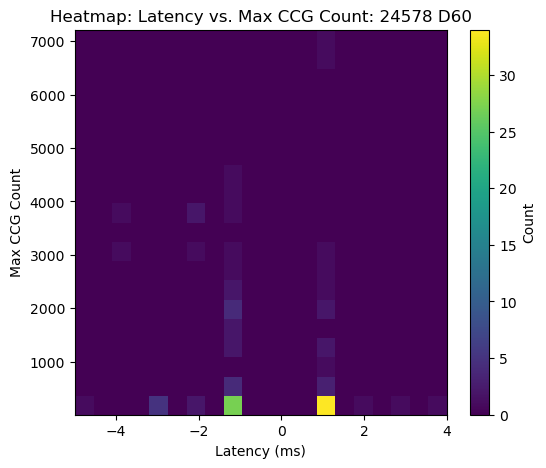

In [22]:
plot_func_pair_metrics(fp24481_49, title="24481 D49")
plot_func_pair_metrics(fp24481_60, title="24481 D60")
plot_func_pair_metrics(fp24578_49, title="24578 D49")
plot_func_pair_metrics(fp24578_60, title="24578 D60")

In [54]:
def plot_comparison_func_pair_metrics(func_pairs_list, labels, title="Chip ID", output_path=None):
    """
    For a list of functional pair dictionaries, extract metrics and plot overlapped histograms
    for latency, p_fast, and max CCG peak, and a 2D heatmap for latency vs. max CCG peak.
    
    Parameters:
      func_pairs_list (list of dict): Each dict is a functional pair dictionary.
      title (str): Title string to append to each plot title (default "Chip ID").
      labels (list of str): List of labels for each dataset.
      output_path (str): Path to save the plot (default None).
    """
    _DEFAULT_COLORS = ["blue", "red", "green", "purple", "orange"]
    n_datasets = len(func_pairs_list)
    colors = _DEFAULT_COLORS[:n_datasets]
    
    # Prepare lists for each dataset.
    all_latencies = []
    all_pfast = []
    all_max_peaks = []
    for fp in func_pairs_list:
        latencies, p_fast_values, max_peaks = extract_func_pair_metrics(fp)
        all_latencies.append(latencies)
        all_pfast.append(p_fast_values)
        all_max_peaks.append(max_peaks)
    
    # Overlapped histograms
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # Latency histogram
    for i, lats in enumerate(all_latencies):
        axs[0].hist(lats, bins=20, color=colors[i], alpha=0.5, label=f"{labels[i]}")
    axs[0].set_title(f"Latency Distribution (ms): {title}")
    axs[0].set_xlabel("Latency (ms)")
    axs[0].set_ylabel("Count")
    axs[0].legend()
    
    # p_fast histogram
    for i, pvals in enumerate(all_pfast):
        axs[1].hist(pvals, bins=20, color=colors[i], alpha=0.5, label=f"{labels[i]}")
    axs[1].set_title(f"p_fast Distribution: {title}")
    axs[1].set_xlabel("p_fast")
    axs[1].set_ylabel("Count")
    axs[1].legend()
    
    # Max CCG peak histogram
    for i, peaks in enumerate(all_max_peaks):
        axs[2].hist(peaks, bins=20, color=colors[i], alpha=0.5, label=f"{labels[i]}")
    axs[2].set_title(f"Max CCG Peak Distribution: {title}")
    axs[2].set_xlabel("Max CCG Count")
    axs[2].set_ylabel("Count")
    axs[2].legend()
    
    plt.tight_layout()
    if output_path:
        save_path = os.path.join(output_path, f"metric_comparison_{title}.png")
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()    


In [55]:
plot_comparison_func_pair_metrics(fplist_24481, title="24481", labels=labels_24481, output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/distributions/')
plot_comparison_func_pair_metrics(fplist_24578, title="24578", labels=labels_24578, output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/distributions/')

In [ ]:
def spatial_analysis(sd, func_pairs, title="Chip ID: Day"):
    """
    Analyze the spatial distribution of functional pairs.
    
    For each functional pair (sender, receiver), the function:
      - Computes the distance between the two neurons using a precomputed distance matrix.
      - Extracts the maximum CCG count (as a proxy for connection strength).
      
    It then plots:
      1. A histogram of the distances between all functional pairs.
      2. A scatter plot of maximum CCG count versus distance.
      
    Parameters:
      sd : SpikeData object
          Contains neuron positions (retrieved via get_neuron_positions(sd)).
      func_pairs : dict
          Dictionary with keys as (sender, receiver) tuples and values containing connectivity info.
      title : str
          Title string to append to each plot title (default "Chip ID: Day").
    """
    # Get neuron positions (assumed to be an array of shape (n_neurons, 2))
    positions = get_neuron_positions(sd)
    
    # Compute the pairwise distance matrix.
    dist_matrix = compute_distance_matrix(positions)
    
    distances = []
    latencies = []
    for (sender, receiver), info in func_pairs.items():
        # Look up the distance from the precomputed matrix.
        d = dist_matrix[sender, receiver]
        distances.append(d)
        latencies.append(np.max(info['latency']))
    
    distances = np.array(distances)
    latencies = np.array(latencies)
    
    # Plot histogram of distances.
    plt.figure(figsize=(6,4))
    plt.hist(distances, bins=20, color='orchid')
    plt.xlabel("Distance between Neurons")
    plt.ylabel("Count")
    plt.title(f"Distribution of Spatial Separations {title}")
    plt.show()
    
    # Scatter plot of CCG peak (ms) vs. distance.
    plt.figure(figsize=(6,4))
    plt.scatter(distances, latencies, color='teal', alpha=0.7)
    plt.xlabel("Distance between Neurons")
    plt.ylabel("CCG Peak (ms)")
    plt.title(f"CCG Peak vs. Distance{title}")
    plt.show()


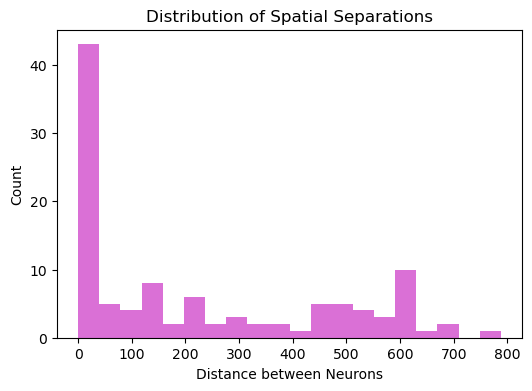

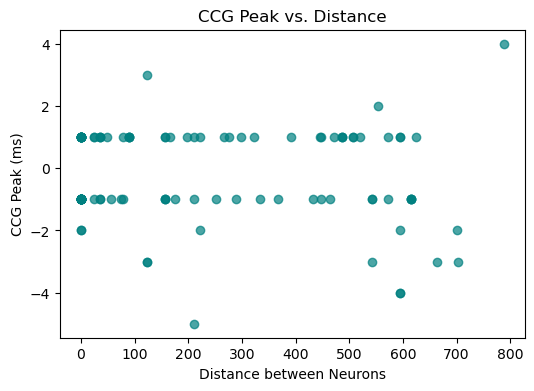

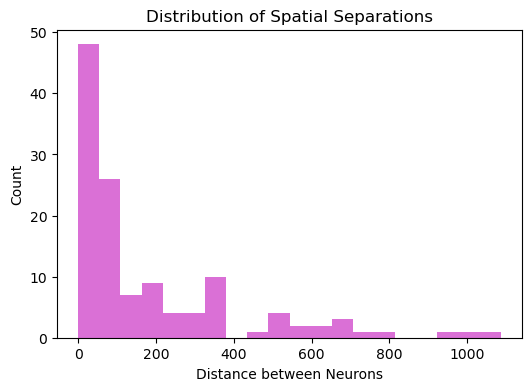

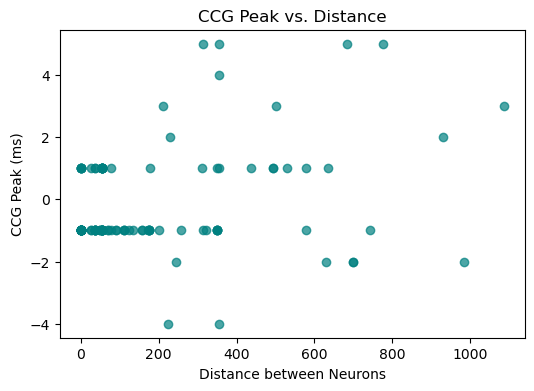

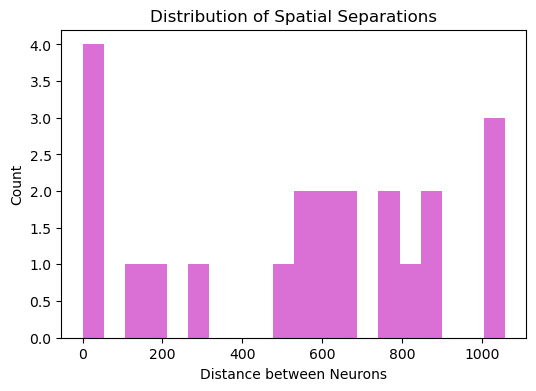

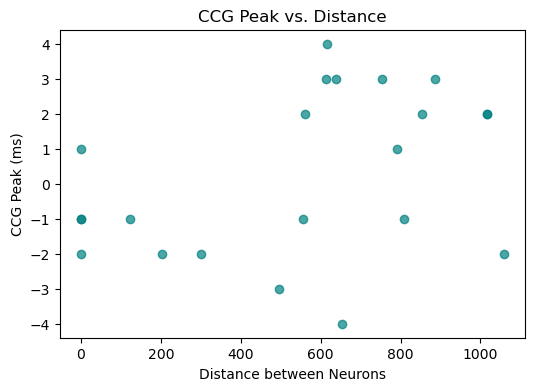

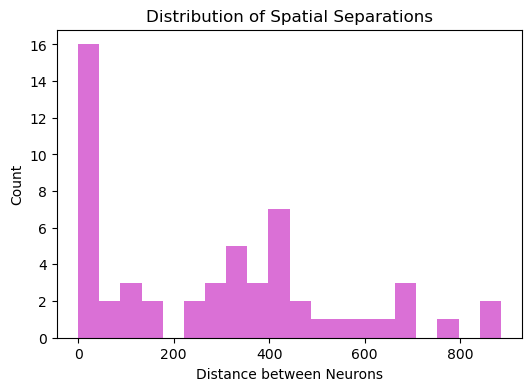

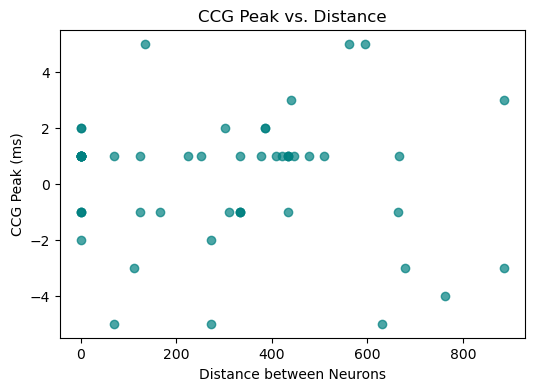

In [19]:
spatial_analysis(sd24578_60, fp24578_60)
spatial_analysis(sd24578_49, fp24578_49)
spatial_analysis(sd24481_60, fp24481_60)
spatial_analysis(sd24481_49, fp24481_49)

In [ ]:
def spatial_vs_parameters(sd, func_pairs, title="Chip ID: Day"):
    """
    For each functional pair, look up the distance (using a distance matrix) 
    and then plot:
      - Latency (ms) vs. distance.
      - p_fast vs. distance.
      
    Parameters:
      sd: SpikeData object (provides neuron positions via get_neuron_positions(sd))
      func_pairs: dict of functional pairs.
      title: string to append to each plot title.
    """
    positions = get_neuron_positions(sd)
    dist_matrix = compute_distance_matrix(positions)
    
    distances = []
    latencies = []
    p_fast_vals = []
    for (sender, receiver), info in func_pairs.items():
        distances.append(dist_matrix[sender, receiver])
        latencies.append(info['latency'])
        p_fast_vals.append(info['p_fast'])
    distances = np.array(distances)
    latencies = np.array(latencies)
    p_fast_vals = np.array(p_fast_vals)
    
    # Plot latency vs. distance
    plt.figure(figsize=(6,4))
    plt.scatter(distances, latencies, color='teal', alpha=0.7)
    plt.xlabel("Distance between Neurons")
    plt.ylabel("Latency (ms)")
    plt.title(f"Latency vs. Distance: {title}")
    plt.show()
    
    # Plot p_fast vs. distance
    plt.figure(figsize=(6,4))
    plt.scatter(distances, p_fast_vals, color='coral', alpha=0.7)
    plt.xlabel("Distance between Neurons")
    plt.ylabel("p_fast")
    plt.title(f"p_fast vs. Distance: {title}")
    plt.show()

def plot_presynaptic_mean_isi_vs_transmission(sd, func_pairs, title="Chip ID: Day"):
    """
    For each functional pair, compute the mean ISI of the presynaptic neuron
    and plot it versus the p_fast value (spike transmission probability metric).
    
    Parameters:
      sd: SpikeData object (contains sd.train for spike times)
      func_pairs: dict of functional pairs.
      title: string appended to the plot title.
    """
    mean_isis = []
    p_fast_vals = []
    for (sender, receiver), info in func_pairs.items():
        isis = isi(sd, sender)
        if len(isis) > 0:
            mean_isi = np.mean(isis)
        else:
            mean_isi = np.nan
        mean_isis.append(mean_isi)
        p_fast_vals.append(info['p_fast'])
    
    mean_isis = np.array(mean_isis)
    p_fast_vals = np.array(p_fast_vals)
    
    plt.figure(figsize=(6,4))
    plt.scatter(mean_isis, p_fast_vals, color='mediumorchid', alpha=0.7)
    plt.xlabel("Mean ISI of Presynaptic Neuron (ms)")
    plt.ylabel("p_fast")
    plt.title(f"Presynaptic Mean ISI vs. p_fast: {title}")
    plt.show()

def plot_presynaptic_cv2_vs_transmission(sd, func_pairs, title="Chip ID: Day"):
    """
    For each functional pair, compute the CV2 of the presynaptic neuron's ISIs
    and plot it versus the p_fast value.
    
    Parameters:
      sd: SpikeData object.
      func_pairs: dict of functional pairs.
      title: string appended to the plot title.
    """
    cv2_vals = []
    p_fast_vals = []
    for (sender, receiver), info in func_pairs.items():
        isis = isi(sd, sender)
        cv2_val = cv2(isis)
        cv2_vals.append(cv2_val)
        p_fast_vals.append(info['p_fast'])
    
    cv2_vals = np.array(cv2_vals)
    p_fast_vals = np.array(p_fast_vals)
    
    plt.figure(figsize=(6,4))
    plt.scatter(cv2_vals, p_fast_vals, color='darkorange', alpha=0.7)
    plt.xlabel("Presynaptic CV2")
    plt.ylabel("p_fast")
    plt.title(f"Presynaptic CV2 vs. p_fast: {title}")
    plt.show()

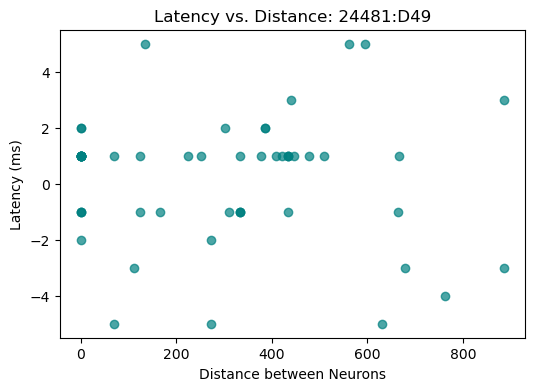

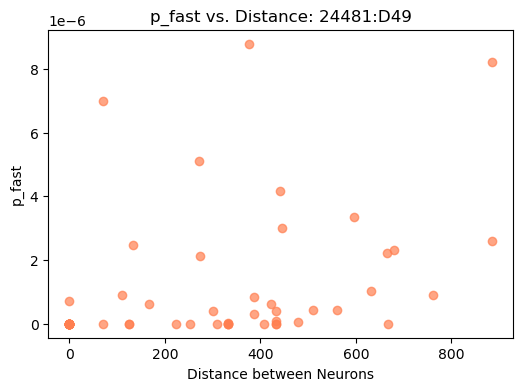

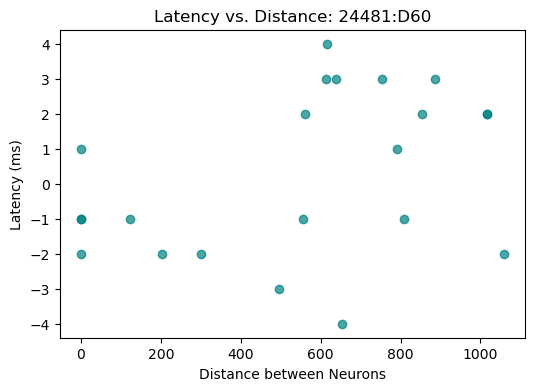

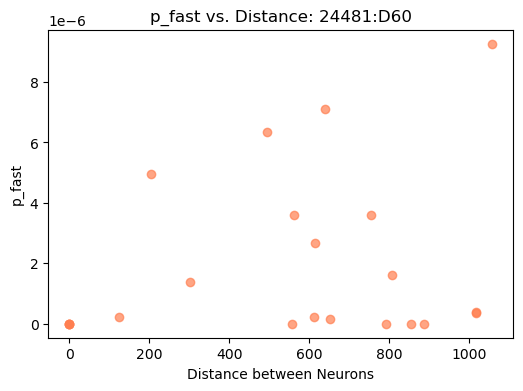

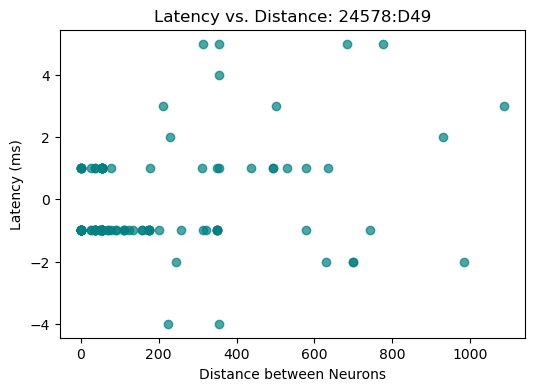

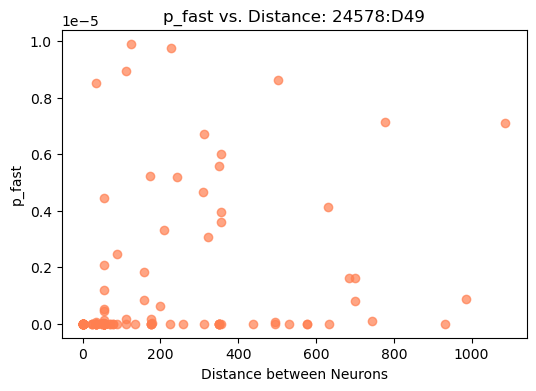

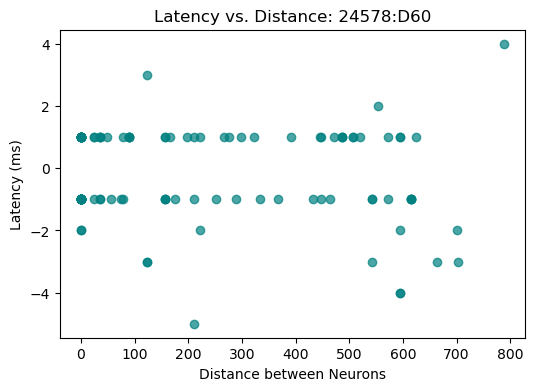

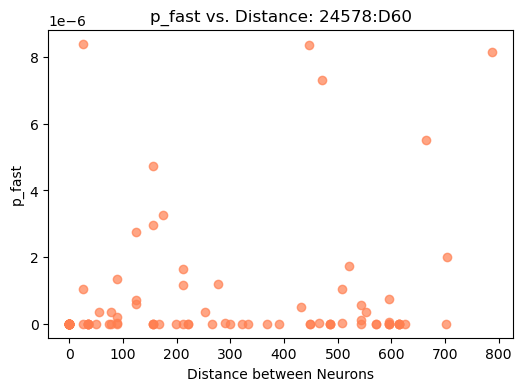

In [24]:
spatial_vs_parameters(sd24481_49, fp24481_49, "24481:D49")
spatial_vs_parameters(sd24481_60, fp24481_60, "24481:D60")
spatial_vs_parameters(sd24578_49, fp24578_49, "24578:D49")
spatial_vs_parameters(sd24578_60, fp24578_60, "24578:D60")

In [50]:
def plot_comparison_spatial_vs_parameters(sd_list, func_pairs_list, labels, strong_threshold=1e-5, title="Chip ID", output_path=None):
    """
    For each dataset (given as a SpikeData object and corresponding func_pairs),
    plot overlapped scatter plots for:
      - Latency vs. distance.
      - p_fast vs. distance.
      
    Only "strong" pairs (p_fast < strong_threshold) are plotted.
    However, the best fit line is computed from all data points in each dataset.
    The best fit line is drawn in a fixed color (e.g. gold) so it stands out.
    
    Parameters:
      sd_list (list): List of SpikeData objects.
      func_pairs_list (list): List of functional pair dictionaries.
      labels (list): List of dataset labels (order determines assignment).
      strong_threshold (float): p_fast threshold for selecting strong connections.
      title (str): Title string to append.
      output_path (str): Path to save the plot (default None).
    """
    _DEFAULT_COLORS = ["blue", "red", "green", "purple", "orange"]
    n_datasets = len(sd_list)
    colors = _DEFAULT_COLORS[:n_datasets]
    best_fit_color = "gold"  # Color for best fit lines
    
    # Assume all datasets share the same spatial coordinate system; use positions from the first.
    positions = get_neuron_positions(sd_list[0])
    dist_matrix = compute_distance_matrix(positions)
    
    # Plot: Latency vs. Distance
    plt.figure(figsize=(6,4))
    for i, (sd, fp) in enumerate(zip(sd_list, func_pairs_list)):
        distances = []
        latencies = []
        p_fast_vals = []
        for (sender, receiver), info in fp.items():
            distances.append(dist_matrix[sender, receiver])
            latencies.append(info['latency'])
            p_fast_vals.append(info['p_fast'])
        distances = np.array(distances)
        latencies = np.array(latencies)
        p_fast_vals = np.array(p_fast_vals)
        
        # Only plot strong pairs (for visualization)
        strong_idx = p_fast_vals < strong_threshold
        plt.scatter(distances[strong_idx], latencies[strong_idx], color=colors[i],
                    alpha=0.7, label=f"{labels[i]}")
        
        # Compute best fit line from all data points
        coeffs = np.polyfit(distances, latencies, 1)
        poly = np.poly1d(coeffs)
        x_line = np.linspace(distances.min(), distances.max(), 100)
        y_line = poly(x_line)
        plt.plot(x_line, y_line, color=colors[i], linestyle='--', linewidth=2)
        
    plt.xlabel("Distance (um)")
    plt.ylabel("Latency (ms)")
    plt.title(f"Latency vs. Distance: {title}")
    plt.legend()
    if output_path:
        save_path = os.path.join(output_path, f"latency_distance_{title}.png")
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()
    
    # Plot: p_fast vs. Distance
    plt.figure(figsize=(6,4))
    for i, (sd, fp) in enumerate(zip(sd_list, func_pairs_list)):
        distances = []
        p_fast_vals = []
        for (sender, receiver), info in fp.items():
            distances.append(dist_matrix[sender, receiver])
            p_fast_vals.append(info['p_fast'])
        distances = np.array(distances)
        p_fast_vals = np.array(p_fast_vals)
        
        # Only plot strong pairs (for visualization)
        strong_idx = p_fast_vals < strong_threshold
        plt.scatter(distances[strong_idx], p_fast_vals[strong_idx], color=colors[i],
                    alpha=0.7, label=f"{labels[i]}")
        
        # Compute best fit line from all data points
        coeffs = np.polyfit(distances, p_fast_vals, 1)
        poly = np.poly1d(coeffs)
        x_line = np.linspace(distances.min(), distances.max(), 100)
        y_line = poly(x_line)
        plt.plot(x_line, y_line, color=colors[i], linestyle='--', linewidth=2)
        
    plt.xlabel("Distance (um)")
    plt.ylabel("p_fast")
    plt.title(f"p_fast vs. Distance: {title}")
    plt.legend()
    if output_path:
        save_path = os.path.join(output_path, f"pfast_distance_{title}.png")
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()


In [52]:
plot_comparison_spatial_vs_parameters(sdlist_24481, fplist_24481, labels_24481, title="24481", output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/vs-distance/')
plot_comparison_spatial_vs_parameters(sdlist_24578, fplist_24578, labels_24578, title="24578", output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/vs-distance/')

In [17]:
def plot_comparison_mean_isi_vs_transmission(sd_list, func_pairs_list, labels, title="Chip ID", output_path=None):
    """
    For each dataset, compute the presynaptic mean ISI for each functional pair and plot it versus p_fast.
    Overlapped plots are generated.
    
    Parameters:
      sd_list (list): List of SpikeData objects.
      func_pairs_list (list): List of func_pairs dictionaries.
      labels (list): List of dataset labels.
      title (str): Title to append.
      output_path (str): Path to save the plot (default None).
    """
    _DEFAULT_COLORS = ["blue", "red", "green", "purple", "orange"]

    n_datasets = len(sd_list)
    colors = _DEFAULT_COLORS[:n_datasets]
    
    plt.figure(figsize=(6,4))
    for i, (sd, fp) in enumerate(zip(sd_list, func_pairs_list)):
        mean_isis = []
        p_fast_vals = []
        for (sender, receiver), info in fp.items():
            spike_train = sd.train[sender]
            isis = np.diff(spike_train)
            mean_isi = np.mean(isis) if len(isis) > 0 else np.nan
            mean_isis.append(mean_isi)
            p_fast_vals.append(info['p_fast'])
        mean_isis = np.array(mean_isis)
        p_fast_vals = np.array(p_fast_vals)
        plt.scatter(mean_isis, p_fast_vals, color=colors[i], alpha=0.7, label=f"{labels[i]}")
    plt.xlabel("Presynaptic Mean ISI (ms)")
    plt.ylabel("p_fast")
    plt.title(f"Presynaptic Mean ISI vs. p_fast: {title}")
    plt.legend()
    if output_path:
        save_path = os.path.join(output_path, f"isi_pfast_{title}.png")
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

def plot_comparison_cv2_vs_transmission(sd_list, func_pairs_list, labels, title="Chip ID", output_path=None):
    """
    For each dataset, compute the presynaptic CV2 for each functional pair using the
    cv2 function from the SpikeData object and plot it versus p_fast.
    Overlapped plots are generated.
    
    Parameters:
      sd_list (list): List of SpikeData objects.
      func_pairs_list (list): List of func_pairs dictionaries.
      labels (list): List of dataset labels.
      title (str): Title to append.
      output_path (str): Path to save the plot (default None).
    """
    _DEFAULT_COLORS = ["blue", "red", "green", "purple", "orange"]

    n_datasets = len(sd_list)
    colors = _DEFAULT_COLORS[:n_datasets]
    
    plt.figure(figsize=(6,4))
    for i, (sd, fp) in enumerate(zip(sd_list, func_pairs_list)):
        cv2_vals = []
        p_fast_vals = []
        for (sender, receiver), info in fp.items():
            # Instead of computing ISIs manually, we call cv2 with the SpikeData object and neuron index.
            cv2_val = cv2(sd, neuron=[sender])
            cv2_vals.append(cv2_val)
            p_fast_vals.append(info['p_fast'])
        cv2_vals = np.array(cv2_vals)
        p_fast_vals = np.array(p_fast_vals)
        plt.scatter(cv2_vals, p_fast_vals, color=colors[i], alpha=0.7, label=f"{labels[i]}")
    plt.xlabel("Presynaptic CV2")
    plt.ylabel("p_fast")
    plt.title(f"Presynaptic CV2 vs. p_fast: {title}")
    plt.legend()
    if output_path:
        save_path = os.path.join(output_path, f"cv2_pfast_{title}.png")
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()


In [19]:
plot_comparison_mean_isi_vs_transmission(sdlist_24481, fplist_24481, labels=labels_24481, title="24481", output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/vs-pfast/')
plot_comparison_mean_isi_vs_transmission(sdlist_24578, fplist_24578, labels=labels_24578, title="24578", output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/vs-pfast/')
plot_comparison_cv2_vs_transmission(sdlist_24481, fplist_24481, labels=labels_24481, title="24481", output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/vs-pfast/')
plot_comparison_cv2_vs_transmission(sdlist_24578, fplist_24578, labels=labels_24578, title="24578", output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/vs-pfast/')

KeyError: 0

<Figure size 600x400 with 0 Axes>

In [ ]:

from analysis.bursting_sd import compute_burst_index

def plot_comparison_burst_vs_transmission(sd_list, func_pairs_list, title="Chip ID: Day", burst_bin_size=40):
    """
    For each dataset, compute the burst index for each neuron (per neuron)
    and then, for each functional pair, extract the presynaptic neuron's burst index.
    Plot burst index vs. p_fast with overlapping scatter plots.
    
    Parameters:
      sd_list (list): List of SpikeData objects.
      func_pairs_list (list): List of functional pair dictionaries.
      title (str): Title to append.
      burst_bin_size (float): Bin size (ms) for burst index computation.
    """
    _DEFAULT_COLORS = ["blue", "red", "green", "purple", "orange"]

    n_datasets = len(sd_list)
    colors = _DEFAULT_COLORS[:n_datasets]
    
    plt.figure(figsize=(6,4))
    for i, (sd, fp) in enumerate(zip(sd_list, func_pairs_list)):
        n_neurons = len(sd.train)
        burst_indices = np.zeros(n_neurons)
        for j in range(n_neurons):
            spike_times = sd.train[j]
            # Create a dummy object for the single neuron's spike train.
            dummy_sd = type('dummy', (object,), {})()
            dummy_sd.train = [spike_times]
            burst_indices[j] = compute_burst_index(dummy_sd, bin_size=burst_bin_size)
        
        burst_presyn = []
        p_fast_vals = []
        for (sender, receiver), info in fp.items():
            burst_presyn.append(burst_indices[sender])
            p_fast_vals.append(info['p_fast'])
        burst_presyn = np.array(burst_presyn)
        p_fast_vals = np.array(p_fast_vals)
        plt.scatter(burst_presyn, p_fast_vals, color=colors[i], alpha=0.7, label=f"Dataset {i+1}")
    plt.xlabel("Presynaptic Burst Index")
    plt.ylabel("p_fast")
    plt.title(f"Presynaptic Burst Index vs. Transmission: {title}")
    plt.legend()
    plt.show()

def plot_comparison_burst_vs_latency(sd_list, func_pairs_list, title="Chip ID: Day", burst_bin_size=40):
    """
    For each dataset, compute the burst index for each neuron,
    then for each functional pair extract the presynaptic neuron's burst index
    and plot it versus the latency (ms).
    
    Parameters:
      sd_list (list): List of SpikeData objects.
      func_pairs_list (list): List of functional pair dictionaries.
      title (str): Title to append.
      burst_bin_size (float): Bin size (ms) for burst index computation.
    """
    _DEFAULT_COLORS = ["blue", "red", "green", "purple", "orange"]

    n_datasets = len(sd_list)
    colors = _DEFAULT_COLORS[:n_datasets]
    
    plt.figure(figsize=(6,4))
    for i, (sd, fp) in enumerate(zip(sd_list, func_pairs_list)):
        n_neurons = len(sd.train)
        burst_indices = np.zeros(n_neurons)
        for j in range(n_neurons):
            spike_times = sd.train[j]
            dummy_sd = type('dummy', (object,), {})()
            dummy_sd.train = [spike_times]
            burst_indices[j] = compute_burst_index(dummy_sd, bin_size=burst_bin_size)
        
        burst_presyn = []
        latencies = []
        for (sender, receiver), info in fp.items():
            burst_presyn.append(burst_indices[sender])
            latencies.append(info['latency'])
        burst_presyn = np.array(burst_presyn)
        latencies = np.array(latencies)
        plt.scatter(burst_presyn, latencies, color=colors[i], alpha=0.7, label=f"Dataset {i+1}")
    plt.xlabel("Presynaptic Burst Index")
    plt.ylabel("Latency (ms)")
    plt.title(f"Presynaptic Burst Index vs. Latency: {title}")
    plt.legend()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper functions assumed to exist ---
# get_neuron_positions(sd) : returns an array of (x, y) positions.
# compute_distance_matrix(positions) : returns pairwise Euclidean distances.

def split_func_pairs_by_latency(func_pairs, short_thresh=5, medium_thresh=10):
    """
    Split the functional pairs into two groups based on latency.
    
    Parameters:
      func_pairs (dict): Functional pairs with each value having a 'latency' key.
      short_thresh (float): Upper bound for the short-latency group (in ms).
      medium_thresh (float): Upper bound for the medium-latency group (in ms).
      
    Returns:
      tuple: Two dictionaries:
         - short_latency: Pairs with latency <= short_thresh.
         - medium_latency: Pairs with latency > short_thresh and <= medium_thresh.
    """
    short_latency = {}
    medium_latency = {}
    for key, info in func_pairs.items():
        latency = info['latency']
        if latency <= short_thresh:
            short_latency[key] = info
        elif latency <= medium_thresh:
            medium_latency[key] = info
    return short_latency, medium_latency

def plot_latency_subsets_distributions(func_pairs, short_thresh=5, medium_thresh=10, title="Chip ID: Day"):
    """
    Plot distribution histograms of latency, p_fast, and max CCG peak 
    for two latency subsets: short (<short_thresh) and medium (short_thresh to medium_thresh).
    
    Parameters:
      func_pairs (dict): Functional pairs dictionary.
      short_thresh (float): Upper bound for short-latency group.
      medium_thresh (float): Upper bound for medium-latency group.
      title (str): Title string to append.
    """
    short_pairs, medium_pairs = split_func_pairs_by_latency(func_pairs, short_thresh, medium_thresh)
    
    # Extract metrics for each subset.
    def extract_metrics(fp):
        lats = []
        pvals = []
        peaks = []
        for key, info in fp.items():
            lats.append(info['latency'])
            pvals.append(info['p_fast'])
            peaks.append(np.max(info['ccg']))
        return np.array(lats), np.array(pvals), np.array(peaks)
    
    lat_short, p_short, peaks_short = extract_metrics(short_pairs)
    lat_med, p_med, peaks_med = extract_metrics(medium_pairs)
    
    # Plot overlapped histograms for latency.
    plt.figure(figsize=(6,4))
    plt.hist(lat_short, bins=20, color='blue', alpha=0.5, label=f"Latency <= {short_thresh} ms")
    plt.hist(lat_med, bins=20, color='red', alpha=0.5, label=f"{short_thresh} ms < Latency <= {medium_thresh} ms")
    plt.xlabel("Latency (ms)")
    plt.ylabel("Count")
    plt.title(f"Latency Distribution by Subset: {title}")
    plt.legend()
    plt.show()
    
    # Similarly for p_fast.
    plt.figure(figsize=(6,4))
    plt.hist(p_short, bins=20, color='blue', alpha=0.5, label=f"Latency <= {short_thresh} ms")
    plt.hist(p_med, bins=20, color='red', alpha=0.5, label=f"{short_thresh} ms < Latency <= {medium_thresh} ms")
    plt.xlabel("p_fast")
    plt.ylabel("Count")
    plt.title(f"p_fast Distribution by Latency Subset: {title}")
    plt.legend()
    plt.show()
    
    # And for max CCG peaks.
    plt.figure(figsize=(6,4))
    plt.hist(peaks_short, bins=20, color='blue', alpha=0.5, label=f"Latency <= {short_thresh} ms")
    plt.hist(peaks_med, bins=20, color='red', alpha=0.5, label=f"{short_thresh} ms < Latency <= {medium_thresh} ms")
    plt.xlabel("Max CCG Count")
    plt.ylabel("Count")
    plt.title(f"CCG Peak Distribution by Latency Subset: {title}")
    plt.legend()
    plt.show()

def plot_spatial_connectivity_by_latency(sd, func_pairs, short_thresh=5, medium_thresh=10, title="Chip ID: Day"):
    """
    Plot a connectivity map showing spatial footprints for two latency subsets.
    
    The function splits the functional pairs into short and medium latency groups,
    then plots the neuron positions and overlays connection arrows:
      - Short-latency pairs are drawn in blue.
      - Medium-latency pairs are drawn in red.
    
    Parameters:
      sd: SpikeData object (provides neuron positions via get_neuron_positions)
      func_pairs: Functional pairs dictionary.
      short_thresh (float): Upper bound for short latency (ms).
      medium_thresh (float): Upper bound for medium latency (ms).
      title (str): Title string to append.
    """
    short_pairs, medium_pairs = split_func_pairs_by_latency(func_pairs, short_thresh, medium_thresh)
    positions = get_neuron_positions(sd)
    # Precompute distance matrix (if needed for consistency; here we only need positions).
    # dist_matrix = compute_distance_matrix(positions)
    
    plt.figure(figsize=(8,8))
    # Plot neuron positions.
    plt.scatter(positions[:,0], positions[:,1], color='lightgray', s=30, label="Neurons")
    
    # Plot arrows for short-latency pairs (blue).
    for (sender, receiver), info in short_pairs.items():
        start = positions[sender]
        end = positions[receiver]
        plt.arrow(start[0], start[1], end[0]-start[0], end[1]-start[1],
                  color='blue', alpha=0.8, linewidth=2, head_width=5, length_includes_head=True)
    
    # Plot arrows for medium-latency pairs (red).
    for (sender, receiver), info in medium_pairs.items():
        start = positions[sender]
        end = positions[receiver]
        plt.arrow(start[0], start[1], end[0]-start[0], end[1]-start[1],
                  color='red', alpha=0.8, linewidth=2, head_width=5, length_includes_head=True)
    
    plt.title(f"Spatial Connectivity by Latency Subset: {title}")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.legend(loc='best')
    plt.show()

# --- Example usage:
# Suppose you have a SpikeData object 'sd' and functional pairs dictionary 'fp'.
# To see the latency distributions and spatial connectivity split by latency:
# plot_latency_subsets_distributions(fp, short_thresh=5, medium_thresh=10, title="Chip 24578: Day 60")
# plot_spatial_connectivity_by_latency(sd, fp, short_thresh=5, medium_thresh=10, title="Chip 24578: Day 60")
